# Find all Power Factors

In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
systems_cleaned = pd.read_csv('../../../data/core/systems_cleaned.csv')
systems_cleaned.columns

Index(['system_id', 'system_public_name', 'site_location',
       'timezone_or_utc_offset', 'latitude', 'longitude', 'elevation_m',
       'dc_capacity_kW', 'kg_climate', 'pvcz_composite', 'pvcz_t_rack',
       'pvcz_t_roof', 'pvcz_humidity', 'pvcz_wind', 'tracking', 'type',
       'azimuth', 'tilt', 'first_timestamp', 'last_timestamp', 'years',
       'number_records', 'dataset_size_mb', 'available_sensor_channels',
       'qa_status', 'qa_issue', 'first_year', 'is_prize_data',
       'is_lake_parquet_data', 'is_lake_csv_data', 'has_irradiance_data',
       'has_ambient_temperature_data', 'has_temperature_data',
       'has_power_data', 'has_current_data', 'has_voltage_data', 'has_ac_data',
       'has_dc_data', 'module_type', 'simplified_type', 'system_source'],
      dtype='str')

In [3]:
metrics_dir = Path("../../../data/raw/parquet-metrics/")
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()
metrics_id_set = set(metrics_df.system_id)

# Early experimentation

## Experiment until we have a good sense of power-factor names.

In [111]:
system_id = 1203
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]

In [112]:
relevant_rows_metrics

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
143,1203,2889,ac_power,AC power,W,W,1.000000,0.000000,ac_meter_1_power_kW+ac_meter_2_power_kW,avg,NaN,NaN,,ac_power__2889
144,1203,2890,dc_power,DC power,W,W,1.000000,0.000000,inv1_dc_power_hW+inv2_dc_power_hW,avg,NaN,NaN,,dc_power__2890
145,1203,2895,inv1_ac_power_hW,AC power,W,W,100.000000,0.000000,,avg,NaN,NaN,,inv1_ac_power_hw__2895
146,1203,2896,inv1_dc_power_hW,DC power,W,W,100.000000,0.000000,,avg,NaN,NaN,,inv1_dc_power_hw__2896
147,1203,2902,inv2_ac_power_hW,AC power,W,W,100.000000,0.000000,,avg,NaN,NaN,,inv2_ac_power_hw__2902
148,1203,2903,inv2_dc_power_hW,DC power,W,W,100.000000,0.000000,,avg,NaN,NaN,,inv2_dc_power_hw__2903
149,1203,2911,ac_inverter_power,AC power,W,W,1.000000,0.000000,inv1_ac_power_hW+inv2_ac_power_hW,avg,NaN,NaN,,ac_inverter_power__2911
150,1203,2898,inv1_ac_current,AC current,A,A,1.000000,0.000000,,avg,NaN,NaN,,inv1_ac_current__2898
151,1203,2905,inv2_ac_current,AC current,A,A,1.000000,0.000000,,avg,NaN,NaN,,inv2_ac_current__2905
152,1203,2909,ac_meter_1_power_kW,AC power,kW,W,1000.000000,0.000000,,avg,NaN,NaN,,ac_meter_1_power_kw__2909


## Helper Functions

In [113]:
def metrics_search_for_fragment_df(df: pd.DataFrame, fragment: str):
    '''Search for fragments of a name in sensor_name and common_name'''
    fragment = fragment.lower()
    return df[
        (df.loc[:, 'sensor_name'].str.contains(fragment, case=False))
        | (df.loc[:, 'common_name'].str.contains(fragment, case=False))
    ]

In [114]:
def metrics_search_for_two_fragments_df(df: pd.DataFrame, fragment_1: str,
                                        fragment_2: str, and_or: str):
    '''Search for fragments of two names in sensor_name and common name.
    Use and_or to switch between "both" and "at least one" modes'''
    fragment_1 = fragment_1.lower()
    fragment_2 = fragment_2.lower()
    if and_or == 'and':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False)))
            & ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False)))
        ]
    elif and_or == 'or':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False)))
            | ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False)))
        ]

In [115]:
# sample use -- search for ac and power
system_id = 1420
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1165,1420,4812,ac_power_KwAC,AC power,W,W,1000.0,0.0,,avg,NaN,NaN,AE_HID=37939,ac_power_kwac__4812


## Wider Helper Functions

In [9]:
def widened_search_for_fragment_df(df: pd.DataFrame, fragment: str):
    '''Search for a fragment in calc_details and source_type
    as well as in sensor_name and common_name'''
    fragment = fragment.lower()
    return df[
        (df.loc[:, 'sensor_name'].str.contains(fragment, case=False))
        | (df.loc[:, 'common_name'].str.contains(fragment, case=False))
        | (df.loc[:, 'calc_details'].str.contains(fragment, case=False))
        | (df.loc[:, 'source_type'].str.contains(fragment, case=False))
    ]

In [10]:
def widened_search_for_two_fragments_df(df: pd.DataFrame, fragment_1: str,
                                        fragment_2: str, and_or: str):
    '''Search for two fragments in calc_details and source_type
    as well as in sensor_name and common_name'''
    fragment_1 = fragment_1.lower()
    fragment_2 = fragment_2.lower()
    if and_or == 'and':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_1, case=False)))
            & ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_2, case=False)))
        ]
    elif and_or == 'or':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_1, case=False)))
            | ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_2, case=False)))
        ]

## Clarification on units and power-factors

In [11]:
power_data = metrics_search_for_fragment_df(metrics_df, 'pow')
# check term power terms with ac data, not in W or kW
power_data[(power_data['common_name'].str.contains('ac', case=False))
           & ~(power_data['units'].isin(['W', 'kW']))]

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
88,1200,4198,power_factor,AC other,-,-,1.000,0.0,,NaN,NaN,NaN,,power_factor__4198
94,1201,2799,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__2799
141,1202,2805,power_factor,AC other,-,-,1.000,0.0,,NaN,NaN,NaN,,power_factor__2805
154,1203,2901,inv1_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv1_power_factor__2901
155,1203,2908,inv2_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv2_power_factor__2908
449,1276,3038,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__3038
464,1277,3053,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__3053
484,1278,3068,inv1_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv1_power_factor__3068
485,1278,3077,inv2_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv2_power_factor__3077
526,1284,957,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__957


Thus, all power-terms not in W or kW are power factors ('-' or 'na'), energy terms (kWh et c.), and other components of complex power (the kVA and kVAR terms)

In [84]:
def find_aggregate_power_factor_names(print_messages = False):
    '''Grab aggregate power factors and associated data.'''
    global metrics_df, systems_cleaned
    # grab data with power factors -- according to above search
    power_factor_data = metrics_search_for_two_fragments_df(metrics_df, 'factor', 'MtrPF', 'or')
    power_factor_ids = set(power_factor_data.system_id).intersection(set(systems_cleaned.system_id))
    answers_dict = {
        id: [] for id in power_factor_ids
    }
    num_ids = len(power_factor_ids)
    pf_agg_metadata_df = pd.DataFrame(
        np.full(shape=(num_ids, 4), fill_value=False, dtype='bool'),
        index=answers_dict.keys(),
        columns=['has_power_factor_aggregate',
                 'has_power_factor_inverter_aggregate',
                 'has_power_factor_meter_aggregate',
                 'has_power_factor_unknown_aggregate']
    )
    pf_agg_metadata_df = pf_agg_metadata_df.sort_index()
    ac_agg_pf_names = ['power_factor', 'power_factor_1000',
                       'PwrMtrPF_Avg']
    for sensor_name in ac_agg_pf_names:
        exact_name_metrics = metrics_df[
                metrics_df['sensor_name'] == sensor_name
        ]
        for id in set(exact_name_metrics['system_id']).intersection(set(systems_cleaned.system_id)):
            relevant_rows_metrics = metrics_df[(metrics_df['system_id']==id)
                                               & (metrics_df['sensor_name']==sensor_name)]
            if len(relevant_rows_metrics.index) > 1:
                raise RuntimeError(f'System {id} has multiple sensors named {sensor_name}!')
            else:
                pf_agg_metadata_df.loc[id, 'has_power_factor_aggregate'] = True
                ind = relevant_rows_metrics.index[0]
                metric_id = relevant_rows_metrics.loc[ind, 'metric_id']
                common_name = relevant_rows_metrics.loc[ind, 'common_name']
                source_type = relevant_rows_metrics.loc[ind, 'source_type']
                # clean up null values in source_type
                if source_type is np.nan:
                    source_type = 'unknown'
                # find inverter-aggregator modules
                if ('inv' in sensor_name.lower()) or ('inv' in common_name.lower())\
                  or ('inv' in source_type.lower()):
                    answers_dict[id].append({
                        'metric_id': metric_id,
                        'sensor_name': sensor_name,
                        'common_name': common_name,
                        'whole_or_part': 'whole',
                        'source_type': 'inverter',
                    })
                    pf_agg_metadata_df.loc[id, 'has_power_factor_inverter_aggregate'] = True
                # find meter-aggregator modules
                elif ('meter' in sensor_name.lower()) or ('meter' in common_name.lower())\
                  or ('meter' in source_type.lower()):
                    answers_dict[id].append({
                        'metric_id': metric_id,
                        'sensor_name': sensor_name,
                        'common_name': common_name,
                        'whole_or_part': 'whole',
                        'source_type': 'meter',
                    })
                    pf_agg_metadata_df.loc[id, 'has_power_factor_meter_aggregate'] = True
                # find other modules
                else:
                    answers_dict[id].append({
                        'metric_id': metric_id,
                        'sensor_name': sensor_name,
                        'common_name': common_name,
                        'whole_or_part': 'whole',
                        'source_type': 'unknown',
                    })
                    pf_agg_metadata_df.loc[id, 'has_power_factor_unknown_aggregate'] = True
    # quick checks
    for id in power_factor_ids:
        # check for missing entries
        if (len(answers_dict[id]) == 0) and print_messages:
            print(f'System {id} appears to have no obvious AC power aggregator name.')
        # check for duplicates
        elif (len(answers_dict[id]) != 1) and print_messages:
            print(f'System {id} has multiple AC power aggregators!')
            for term in answers_dict[id]:
                print(term)

    return (answers_dict, pf_agg_metadata_df)

In [106]:
agg_power_factor, agg_pf_meta = find_aggregate_power_factor_names(True)

System 1203 appears to have no obvious AC power aggregator name.
System 1278 appears to have no obvious AC power aggregator name.


In [107]:
practice_series = pd.Series(
    {
        'b': 12,
        'a': 13
    }
)
practice_series.sort_index()

a    13
b    12
dtype: int64

In [108]:
agg_power_factor

{33: [{'metric_id': np.int32(596),
   'sensor_name': 'power_factor',
   'common_name': 'AC other',
   'whole_or_part': 'whole',
   'source_type': 'unknown'}],
 34: [{'metric_id': np.int32(2693),
   'sensor_name': 'power_factor_1000',
   'common_name': 'AC other',
   'whole_or_part': 'whole',
   'source_type': 'unknown'}],
 35: [{'metric_id': np.int32(2711),
   'sensor_name': 'power_factor_1000',
   'common_name': 'AC other',
   'whole_or_part': 'whole',
   'source_type': 'unknown'}],
 1284: [{'metric_id': np.int32(957),
   'sensor_name': 'power_factor',
   'common_name': 'AC other',
   'whole_or_part': 'whole',
   'source_type': 'unknown'}],
 4901: [{'metric_id': np.int32(82542),
   'sensor_name': 'PwrMtrPF_Avg',
   'common_name': 'AC power other',
   'whole_or_part': 'whole',
   'source_type': 'meter'}],
 4902: [{'metric_id': np.int32(82640),
   'sensor_name': 'PwrMtrPF_Avg',
   'common_name': 'AC power other',
   'whole_or_part': 'whole',
   'source_type': 'meter'}],
 4903: [{'metric

In [109]:
agg_pf_meta

,has_power_factor_aggregate,has_power_factor_inverter_aggregate,has_power_factor_meter_aggregate,has_power_factor_unknown_aggregate
4,True,False,False,True
33,True,False,False,True
34,True,False,False,True
35,True,False,False,True
1200,True,False,False,True
1201,True,False,False,True
1202,True,False,False,True
1203,False,False,False,False
1276,True,False,False,True
1277,True,False,False,True


1203 and 1278 -- really just inverter power factors, no total!


As the above indicates, quite often inverter data is *not* summed, so we may need to do it ourselves.

### Helper Function

In [77]:
def common_prefix_and_suffix(names_collection, first_name):
    '''Find the common prefix and suffix of a collection of the strings,
    with the first name in the collection set aside for ease of coding.'''
    common_prefix = ''
    j = 0
    good_prefix = True
    max_len = len(first_name)
    while good_prefix:
        if all(
            [name.startswith(common_prefix) for name in names_collection]
        ):
            j += 1
            common_prefix = first_name[0:j]
            if j >= max_len + 1:
                print('Common prefix is whole thing!')
                good_prefix = False
                common_prefix = first_name
        else: # bad prefix, back it up one
            good_prefix = False
            common_prefix = common_prefix[0:-1]
    common_suffix = ''
    j = 0 
    good_suffix = True
    while good_suffix:
        if all(
            [name.endswith(common_suffix) for name in names_collection]
        ):
            j += 1
            common_suffix = first_name[-j:]
            if j >= max_len + 1:
                print('Common prefix is whole thing!')
                good_prefix = False
                common_suffix = first_name
        else: # take the last amendment off
            good_suffix = False
            common_suffix = common_suffix[1:]
    return (common_prefix, common_suffix)


## Finding Remaining Power-factor data


In [78]:
def find_all_power_factor_names():
    '''Add the power-factor partial data to the power-factor complete data.'''
    global metrics_df, systems_cleaned
    # grab the aggregate power names from Step 1
    power_factor_names, pf_agg_metadata_df = find_aggregate_power_factor_names(False)
    # prep my series of booleans for having sub-parts
    num_names = len(power_factor_names.keys())
    pf_parts_metadata_df = pd.DataFrame(
        np.full(shape=(num_names, 4), fill_value=False, dtype='bool'),
        index = power_factor_names.keys(),
        columns=['has_power_factor_subparts',
                 'has_power_factor_inverter_subparts',
                 'has_power_factor_meter_subparts',
                 'has_power_factor_unknown_subparts']
    )
    ac_agg_pf_names = ['power_factor', 'power_factor_1000',
                       'PwrMtrPF_Avg']
    for id in power_factor_names.keys():
        # grab only those metrics with 'factor' or 'MtrPF'
        relevant_rows_metrics = metrics_df[metrics_df['system_id']==id]
        power_factor_metrics = metrics_search_for_two_fragments_df(
            relevant_rows_metrics,
            'factor',
            'MtrPF',
            'or'
        )
        # drop the aggregate names, and power terms
        power_factor_reduced_metrics = power_factor_metrics[
            ~(power_factor_metrics['sensor_name'].isin(ac_agg_pf_names))
        ]
        #see if any terms remaining
        num_subparts = power_factor_reduced_metrics.shape[0]
        if (num_subparts > 1):
            pf_parts_metadata_df.loc[id, 'has_power_factor_subparts'] = True
            # clear inverter and meter types.
            for known_short, known_type in [
                ('inv', 'inverter'), ('meter', 'meter'), ('', 'unknown')
            ]:
                power_factor_known_type = widened_search_for_fragment_df(
                    power_factor_reduced_metrics, known_short
                )
                num_known_type = power_factor_known_type.shape[0]
                if num_known_type > 0:
                    pf_parts_metadata_df.loc[id, f'has_power_factor_{known_type}_subparts'] = True
                    power_factor_known_type = power_factor_known_type.sort_values('sensor_name')
                    power_factor_known_names = power_factor_known_type['sensor_name'].values
                    first_known_name = power_factor_known_names[0]
                    common_prefix, common_suffix = common_prefix_and_suffix(
                        power_factor_known_names, first_known_name
                    )
                    # add the partial names on there
                    for k in range(0, num_known_type):
                        kth_metric = power_factor_known_type.iloc[k, :]
                        kth_sensor_name = kth_metric['sensor_name']
                        if kth_sensor_name.startswith(common_prefix)\
                          and kth_sensor_name.endswith(common_suffix):
                            kth_interior = kth_sensor_name.removeprefix(common_prefix).removesuffix(common_suffix)
                        else:
                            raise ValueError('Bad prefix or suffix!') 
                        power_factor_names[id].append({
                            'metric_id': kth_metric['metric_id'],
                            'sensor_name': kth_sensor_name,
                            'common_name': kth_metric['common_name'],
                            'source_type': known_type,
                            'whole_or_part': 'part',
                            'index': kth_interior
                        })
                    # drop these terms from consideration
                    power_factor_reduced_metrics = power_factor_reduced_metrics.drop(
                        index = power_factor_known_type.index
                    )
        elif num_subparts == 1:
            print(f'System {id} has only one subpart!')
            print(power_factor_reduced_metrics.iloc[0, :])
            raise ValueError('Incorrect subpart description.')
    pf_total_metadata_df = pd.merge(pf_agg_metadata_df, pf_parts_metadata_df, 
                                    how ='inner',
                                    left_index=True,
                                    right_index=True)
    return (power_factor_names, pf_total_metadata_df)
        


In [79]:
pf_names, pf_subdata = find_all_power_factor_names()

In [80]:
pf_names

{33: [{'metric_id': np.int32(596),
   'sensor_name': 'power_factor',
   'common_name': 'AC other',
   'whole_or_part': 'whole',
   'source_type': 'unknown'}],
 34: [{'metric_id': np.int32(2693),
   'sensor_name': 'power_factor_1000',
   'common_name': 'AC other',
   'whole_or_part': 'whole',
   'source_type': 'unknown'}],
 35: [{'metric_id': np.int32(2711),
   'sensor_name': 'power_factor_1000',
   'common_name': 'AC other',
   'whole_or_part': 'whole',
   'source_type': 'unknown'}],
 1284: [{'metric_id': np.int32(957),
   'sensor_name': 'power_factor',
   'common_name': 'AC other',
   'whole_or_part': 'whole',
   'source_type': 'unknown'}],
 4901: [{'metric_id': np.int32(82542),
   'sensor_name': 'PwrMtrPF_Avg',
   'common_name': 'AC power other',
   'whole_or_part': 'whole',
   'source_type': 'meter'}],
 4902: [{'metric_id': np.int32(82640),
   'sensor_name': 'PwrMtrPF_Avg',
   'common_name': 'AC power other',
   'whole_or_part': 'whole',
   'source_type': 'meter'}],
 4903: [{'metric

In [82]:
pf_subdata

,has_power_factor_aggregate,has_power_factor_inverter_aggregate,has_power_factor_meter_aggregate,has_power_factor_unknown_aggregrate,has_power_factor_unknown_aggregate,has_power_factor_subparts,has_power_factor_inverter_subparts,has_power_factor_meter_subparts,has_power_factor_unknown_subparts
4,True,False,False,False,True,False,False,False,False
33,True,False,False,False,True,False,False,False,False
34,True,False,False,False,True,False,False,False,False
35,True,False,False,False,True,False,False,False,False
1200,True,False,False,False,True,False,False,False,False
1201,True,False,False,False,True,False,False,False,False
1202,True,False,False,False,True,False,False,False,False
1203,False,False,False,False,NaN,True,True,False,False
1276,True,False,False,False,True,False,False,False,False
1277,True,False,False,False,True,False,False,False,False


## Compilation of Power-Factor Data

Naming functions for power factors

In [88]:
def ac_power_factor_total_name(source_type: str, has_subparts: bool):
    if has_subparts:
        return f'ac_power_factor_{source_type}_mean'
    else:
        return f'ac_power_factor_{source_type}'


def ac_power_factor_partial_name(source_type: str, ind: int):
    return f'ac_power_factor_{source_type}_{ind}'

In [98]:
def ac_power_factor_dataframe_generator(system_id: int, 
                                        tall_or_wide: str,
                                        error_on_no_data: bool = False,
                                        order_priority: str = 'whole_before_part'):
    '''Make the (tall or wide) pandas DataFrame with all dc power data.
    
    Params:
    system_id: int
        Index of system in systems_cleaned and metric_df
    tall_or_wide: str
        If 'wide', return wide Dataframe
        if 'tall', convert back to a 3-column array.
    error_in_no_data: bool = False
        If True, return an error if the system_id has no power-factor data.
        If False, return None if the system-id has no power factor data.
    order_priority: str, "whole_before_part" or "connect_like_terms"
        If "whole_before_part", puts all aggregate figures before all subdata_figures
        If "connect_like_terms", lists inverter aggregate, then inverter parts,
            then meter aggregate, then meter parts, then unknown together, then unknown parts.

    Return:
    A pandas DataFrame object with the desired data.
    '''
    pf_metric_names, pf_metric_metadata = find_all_power_factor_names()
    try:
        my_pf_names = pf_metric_names[system_id]
    except KeyError:
        if error_on_no_data:
            raise ValueError(f'System {system_id} has no DC power data!')
        else:
            return None
    except BaseException as e:
        raise e
    metric_ids = []
    whole_metric_ids = []
    source_type_metric_ids = {
        'inverter': [],
        'meter': [],
        'unknown': []
    }
    # grab all metric ids, putting the 'whole' category first
    for metric_data_dict in my_pf_names:
        # whole-part distribution
        if metric_data_dict['whole_or_part'] == 'whole':
            metric_ids.insert(0, metric_data_dict['metric_id'])
            whole_metric_ids.append(metric_data_dict['metric_id'])
        elif metric_data_dict['whole_or_part'] == 'part':
            metric_ids.append(metric_data_dict['metric_id'])
        else:
            raise ValueError('The "whole_or_part" result of find_all_power_factor_names()\n'
                             f'is not correct for system {system_id}.')
        # get source-type metric updated.
        source_type_metric_ids[metric_data_dict['source_type']].append(
            metric_data_dict['metric_id']
        )
    # Load only these metrics from the system
    my_system_parquet_data_path = Path(f'../../../../data_ds_project/systems/parquet/{system_id}/')
    my_system_parquet_selection = pq.ParquetDataset(
        my_system_parquet_data_path, filters=[
            ('metric_id', 'in', metric_ids)
        ]
    )
    system_df = my_system_parquet_selection.read().to_pandas()
    # for reference, 4 columns (see
    # https://github.com/openEDI/documentation/blob/main/pvdaq.md#pvdaq_pvdata)
    # measured_on, utc_measured_on, metric_id, value)
    # standard cleaning
    system_df = system_df.drop_duplicates()
    # See if multiple values at a given time
    # if so, forced to replace value by mean value
    if any(system_df.duplicated(subset = ['measured_on', 'metric_id'])):
        system_df.loc[:, 'mean_value'] = system_df.groupby(
            ['measured_on', 'metric_id']
        )['value'].transform('mean')
        system_df = system_df.drop(columns='value')
        system_df = system_df.rename(columns={'mean_value':'value'})
        system_df.drop_duplicates()
    # if still duplicates, forced to drop utc_measured_on,
    # a frequent source of off-by-one-hour errors
    # (and points with the same 'measured_on' but different 'utc_measured_on'
    # have the same value, so it is likely that utc_measured_on is the problem)
    if any(system_df.duplicated(subset = ['measured_on', 'metric_id', 'value'])):
        system_df = system_df.drop(columns='utc_measured_on')
        system_df = system_df.drop_duplicates()
    # ready to widen the columns
    wide_df = system_df.pivot(
        index='measured_on',
        columns='metric_id',
        values='value'
    )
    # reset the metric_id name of the index of columns
    wide_df.columns.name = ''
    # reset the index
    wide_df = wide_df.reset_index()
    # Some systems have part-data and not aggregate data;  
    # amend this mistake.
    # Note that power-factor is always between -1 and 1,
    # so an average is the least-bad choice.  
    for source_type in ('inverter', 'meter', 'unknown'):
        if (pf_metric_metadata.loc[system_id, f'has_power_factor_{source_type}_subparts'])\
          and (not pf_metric_metadata.loc[system_id, f'has_power_factor_{source_type}_aggregate']):
            source_type_total_name = ac_power_factor_total_name(source_type, True)
            wide_df.loc[:, source_type_total_name] = wide_df.apply(
                lambda row: np.mean(
                    [row[j] for j in source_type_metric_ids[source_type]]
                ), axis=1
            )
            whole_metric_ids.append(source_type_total_name)
            source_type_metric_ids[source_type].append(
                source_type_total_name
            )
    # reorder columns according to order_priority
    if order_priority == 'whole_before_part':
        # push the 'whole' columns to the beginning of the pack
        # despite re-ordering earlier, can still be loaded in the wrong order.
        reordered_columns = ['measured_on'] + whole_metric_ids+ (wide_df.columns.drop(
            ['measured_on'] + whole_metric_ids
        ).tolist())
        wide_df = wide_df[reordered_columns]
    elif order_priority == 'connect_like_terms':
        inv_ordered = []
        for j in source_type_metric_ids['inverter']:
            if j in whole_metric_ids:
                inv_ordered.insert(0, j)
            else:
                inv_ordered.append(j)
        meter_ordered = []
        for j in source_type_metric_ids['meter']:
            if j in whole_metric_ids:
                meter_ordered.insert(0, j)
            else:
                meter_ordered.append(j)
        unknown_ordered = []
        for j in source_type_metric_ids['unknown']:
            if j in whole_metric_ids:
                unknown_ordered.insert(0, j)
            else:
                unknown_ordered.append(j)
        reordered_columns = ['measured_on'] + inv_ordered + meter_ordered + unknown_ordered
        wide_df = wide_df[reordered_columns]
    # rename columns
    renamer_dict = dict()
    for metric_data_dict in my_pf_names:
        source_type = metric_data_dict['source_type']
        if metric_data_dict['whole_or_part'] == 'whole':
            renamer_dict[metric_data_dict['metric_id']] = ac_power_factor_total_name(
                source_type, pf_metric_metadata.loc[system_id, f'has_power_factor_{source_type}_subparts']
            )
        elif metric_data_dict['whole_or_part'] == 'part':
            renamer_dict[metric_data_dict['metric_id']] = ac_power_factor_partial_name(
                source_type, metric_data_dict['index']
            )
        else:
            raise ValueError('The "whole_or_part" result of find_all_power_factor_names()\n'
                             f'is not correct for system {system_id}.')
    wide_df = wide_df.rename(columns=renamer_dict)
    # convert back to tall format if that is what we wanted
    if tall_or_wide == 'wide':
        return wide_df
    elif tall_or_wide == 'tall':
        return wide_df.melt(
            id_vars='measured_on',
            value_vars=list(renamer_dict.values()),
            var_name='metric_name',
            value_name='value'
        )
    else:
        raise ValueError('The term "tall_or_wide" must be "tall" or "wide.\n'
                         + f'Recieved {tall_or_wide}')


### Test

In [87]:
test_1203 = ac_power_factor_dataframe_generator(1203, 'wide', False, 'whole_before_part')
test_1203

,measured_on,ac_power_factor_inverter_mean,ac_power_factor_inverter_subsystem_1,ac_power_factor_inverter_subsystem_2
0,2011-01-19 14:30:01,997.0,999.0,995.0
1,2011-01-19 14:45:01,987.5,981.0,994.0
2,2011-01-19 14:48:02,985.5,978.0,993.0
3,2011-01-19 14:51:02,977.5,976.0,979.0
4,2011-01-19 14:54:01,991.5,989.0,994.0
...,...,...,...,...
1545262,2020-07-26 16:55:02,NaN,NaN,999.0
1545263,2020-07-26 17:00:01,NaN,1000.0,NaN
1545264,2020-07-26 17:00:02,NaN,NaN,999.0
1545265,2020-07-26 17:05:01,NaN,999.0,NaN


In [92]:
test_1203.dtypes


measured_on                             datetime64[ns]
ac_power_factor_inverter_mean                  float64
ac_power_factor_inverter_subsystem_1           float64
ac_power_factor_inverter_subsystem_2           float64
dtype: object

In [99]:
for j in pf_names.keys():
    print(j)
    temp_df = ac_power_factor_dataframe_generator(j, 'wide', False, 'connect_like_terms')
    temp_df_numeric = temp_df.select_dtypes(include=np.number)
    print(temp_df_numeric.max())

33

ac_power_factor_unknown    2011.0
dtype: float64
34

ac_power_factor_unknown    1000.0
dtype: float64
35

ac_power_factor_unknown    1000.0
dtype: float64
1284

ac_power_factor_unknown    28.9025
dtype: float64
4901

ac_power_factor_meter    1.003
dtype: float64
4902

ac_power_factor_meter    1.0
dtype: float64
4903

ac_power_factor_meter    1.0
dtype: float64
1416

ac_power_factor_unknown_mean    0.999983
ac_power_factor_unknown_A       0.999983
ac_power_factor_unknown_B       0.999983
ac_power_factor_unknown_C       0.999983
dtype: float64
1289

ac_power_factor_unknown    27.3777
dtype: float64
4

ac_power_factor_unknown    19.7207
dtype: float64
1200

ac_power_factor_unknown    1.008
dtype: float64
1201

ac_power_factor_unknown    1.0
dtype: float64
1202

ac_power_factor_unknown    1.007
dtype: float64
1203

ac_power_factor_inverter_mean    1000.0
ac_power_factor_inverter_1       1000.0
ac_power_factor_inverter_2       1000.0
dtype: float64
1276

ac_power_factor_unknown    0.999

Power factor should be between 0 and 1, but the 1000 variant is natural.  The 27-28 case is confusing -- 27-28 out of 100? 1000?

## Testing ground -- Can ignore after this.

### System 1203

In [49]:
system_id = 1203
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_fragment_df(relevant_rows_metrics, 'factor')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
154,1203,2901,inv1_power_factor,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,inv1_power_factor__2901
155,1203,2908,inv2_power_factor,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,inv2_power_factor__2908


In [51]:
path_1203 = Path(f'../../../../data_ds_project/systems/parquet/1203/')
pq_1203 = pq.ParquetDataset(
    path_1203, filters=[
            ('metric_id', 'in', [2901, 2908])
    ]
)
df_1203 = pq_1203.read().to_pandas()
df_1203 = df_1203.drop_duplicates()
df_1203.tail()

,measured_on,utc_measured_on,metric_id,value
2688789,2020-07-26 16:15:02,2020-07-26 20:15:02,2908,999.0
2688790,2020-07-26 16:35:01,2020-07-26 20:35:01,2901,994.0
2688791,2020-07-26 16:35:02,2020-07-26 20:35:02,2908,988.0
2688792,2020-07-26 16:55:01,2020-07-26 20:55:01,2901,999.0
2688793,2020-07-26 16:55:02,2020-07-26 20:55:02,2908,999.0


In [52]:
df_1203[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2018-11-04 01:05:01  2901         2
2018-11-04 01:05:02  2908         2
2018-11-04 01:25:01  2901         2
2018-11-04 01:25:02  2908         2
2018-11-04 01:45:01  2901         2
                                 ..
2020-07-26 16:15:02  2908         1
2020-07-26 16:35:01  2901         1
2020-07-26 16:35:02  2908         1
2020-07-26 16:55:01  2901         1
2020-07-26 16:55:02  2908         1
Name: count, Length: 2688458, dtype: int64

Test for spread

In [54]:
df_1203[df_1203['measured_on'] == '2018-11-04 01:05:01'].sort_values('metric_id')

,measured_on,utc_measured_on,metric_id,value
2331947,2018-11-04 01:05:01,2018-11-04 05:05:01,2901,0.0
2331948,2018-11-04 01:05:01,2018-11-04 06:05:01,2901,0.0


A Large spread for once.  Is this widespread?

In [55]:
df_1203.loc[:, 'val_min'] = df_1203.groupby(['measured_on', 'metric_id'])['value'].transform('min')
df_1203.loc[:, 'val_max'] = df_1203.groupby(['measured_on', 'metric_id'])['value'].transform('max')
df_1203.loc[:, 'val_spread'] = df_1203['val_max'] - df_1203['val_min']
df_1203[df_1203['val_spread'] > 0.5]

,measured_on,utc_measured_on,metric_id,value,val_min,val_max,val_spread


This is more normal.

In [56]:
df_1203 = df_1203.drop(columns='utc_measured_on')
df_1203.loc[:, 'mean_value'] = df_1203.groupby(['measured_on', 'metric_id'])['value'].transform('mean')
df_1203 = df_1203.drop(columns='value')
df_1203 = df_1203.rename(columns={'mean_value': 'value'})
df_1203 = df_1203.drop_duplicates()

In [100]:
wide_1203 = df_1203.pivot(
    index='measured_on',
    columns='metric_id',
    values='value'
)
wide_1203.columns.name = ''
wide_1203 = wide_1203.reset_index()
rename_cols = dict()
for ind in relevant_rows_metrics.index:
    rename_cols[relevant_rows_metrics.loc[ind, 'metric_id']] = relevant_rows_metrics.loc[ind, 'sensor_name']
wide_1203 = wide_1203.rename(columns=rename_cols)
wide_1203.head()

,measured_on,inv1_power_factor,inv2_power_factor
0,2011-01-19 14:30:01,999.0,995.0
1,2011-01-19 14:45:01,981.0,994.0
2,2011-01-19 14:48:02,978.0,993.0
3,2011-01-19 14:51:02,976.0,979.0
4,2011-01-19 14:54:01,989.0,994.0


In [101]:
wide_1203.describe()

,measured_on,inv1_power_factor,inv2_power_factor
count,1545267,1.343272e+06,1.345186e+06
mean,2015-10-09 08:46:56.523517696,3.969908e+02,4.058258e+02
min,2011-01-19 14:30:01,0.000000e+00,0.000000e+00
25%,2013-04-03 17:55:32,0.000000e+00,0.000000e+00
50%,2015-06-17 14:06:02,0.000000e+00,0.000000e+00
75%,2018-09-03 01:27:31,9.960000e+02,9.940000e+02
max,2020-07-26 17:05:02,1.000000e+03,1.000000e+03
std,NaN,4.848088e+02,4.821438e+02


In [102]:
wide_1203.shape

(1545267, 3)

<Axes: xlabel='inv1_power_factor', ylabel='inv2_power_factor'>

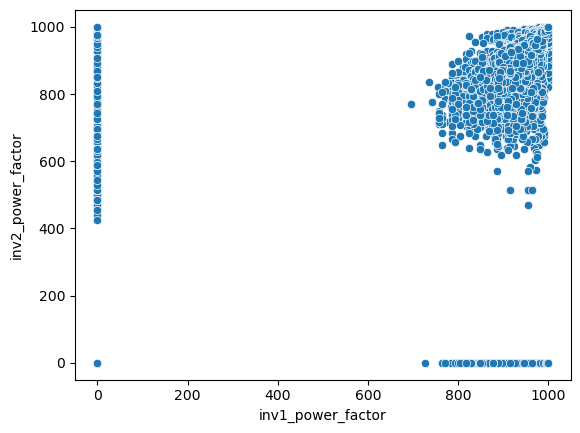

In [104]:
sns.scatterplot(
    data = wide_1203,
    x = 'inv1_power_factor',
    y = 'inv2_power_factor'
)